# 1. Basis of retrieval

Before diving into embeddings and neural rankers, it pays to understand the
*classical* tools they replaced (and still complement). The whole game of
retrieval is:

> given a query $q$ and a collection of documents $\{d_1, d_2, \dots\}$,
> produce a **scalar similarity** $\mathrm{sim}(q, d_i)$ that we can sort by.

Everything else — TF-IDF, BM25, cosine similarity over embeddings, cross-encoders —
is a different choice of `sim`. This notebook builds up four classical choices,
in increasing sophistication:

1. **Jaccard** over token sets (the simplest thing that works).
2. **Dot product** on numeric vectors — including its geometric and
   linear-regression interpretations.
3. The hidden link between Jaccard and the dot product on binary
   bag-of-words vectors.
4. **BM25**, the strongest "classical" sparse retriever and the standard
   baseline in modern RAG papers.

References used to shape this notebook:

- HuggingFace cookbook: ["Advanced RAG on HuggingFace docs"](https://huggingface.co/learn/cookbook/advanced_rag)
- Pinecone learn: ["BM25"](https://www.pinecone.io/learn/series/nlp/rank-bm25/)
- Stanford IR book, ch. 6 ([online](https://nlp.stanford.edu/IR-book/html/htmledition/scoring-term-weighting-and-the-vector-space-model-1.html))

In [1]:
# One tiny corpus, reused throughout this notebook.
# Keep it small enough that you can do every score by hand.
corpus = [
    "the cat sat on the mat",
    "the cat played with the dog",
    "dogs and cats are common pets",
    "neural networks learn vector representations",
    "vector search uses dot products to rank documents",
]

query = "cat and dog"

for i, d in enumerate(corpus):
    print(f"d{i}: {d}")
print(f"\nquery q: {query}")

d0: the cat sat on the mat
d1: the cat played with the dog
d2: dogs and cats are common pets
d3: neural networks learn vector representations
d4: vector search uses dot products to rank documents

query q: cat and dog


## 1.1 The old way: tokenization + Jaccard

The pre-statistical retrieval model thought of a document as a *set of tokens*.
Two pieces of text are similar if they share many tokens.

The **Jaccard index** measures exactly that:

$$
\mathrm{Jaccard}(A, B) \;=\; \frac{|A \cap B|}{|A \cup B|}
$$

where $A$ and $B$ are the token sets. Bounded in $[0, 1]$:

- $1$ when the two token sets are identical,
- $0$ when they share nothing.

We need a *tokenizer*. The crudest one is "lowercase, split on whitespace,
keep word characters only". That's what we use here — it's transparent and
enough to make the geometry obvious.

In [2]:
import re

def tokenize(text: str) -> list[str]:
    # lowercase, keep [a-z0-9]+ runs
    return re.findall(r"[a-z0-9]+", text.lower())

def jaccard(a_tokens, b_tokens) -> float:
    A, B = set(a_tokens), set(b_tokens)
    if not A and not B:
        return 0.0
    return len(A & B) / len(A | B)

q_tok = tokenize(query)
print("query tokens:", q_tok, "-> set:", set(q_tok))

print("\npairwise Jaccard(query, d_i):")
for i, d in enumerate(corpus):
    d_tok = tokenize(d)
    s = jaccard(q_tok, d_tok)
    print(f"  d{i}: jaccard = {s:.3f}   tokens = {set(d_tok)}")

query tokens: ['cat', 'and', 'dog'] -> set: {'cat', 'and', 'dog'}

pairwise Jaccard(query, d_i):
  d0: jaccard = 0.143   tokens = {'cat', 'on', 'mat', 'sat', 'the'}
  d1: jaccard = 0.333   tokens = {'cat', 'the', 'dog', 'played', 'with'}
  d2: jaccard = 0.125   tokens = {'are', 'pets', 'common', 'dogs', 'and', 'cats'}
  d3: jaccard = 0.000   tokens = {'networks', 'vector', 'learn', 'representations', 'neural'}
  d4: jaccard = 0.000   tokens = {'uses', 'search', 'vector', 'documents', 'dot', 'to', 'rank', 'products'}


A few things to notice — these motivate every later improvement:

- **Stopword domination.** "the" carries no information yet contributes to
  the union/intersection. BM25 (1.4) downweights frequent terms; embeddings
  learn to ignore them.
- **Exact-match brittleness.** `"dog"` and `"dogs"` are different *strings*;
  Jaccard treats them as unrelated. Stemming/lemmatization help; embeddings
  kill this problem.
- **No magnitude.** Once a token is in the set, repeating it doesn't matter.
  TF-IDF / BM25 fix this with term frequencies.

## 1.2 The dot product — math, geometry, and "weighted sum of features"

Once we move from sets to *numbers*, similarity becomes a function on
vectors. The dot product is the simplest such function:

$$
\mathbf{a}\cdot\mathbf{b} \;=\; \sum_{i=1}^{n} a_i\, b_i
$$

Two equally important ways to read this formula:

**Geometric.** Up to length, the dot product measures the *angle* between
the vectors:

$$
\mathbf{a}\cdot\mathbf{b} \;=\; \lVert\mathbf{a}\rVert\, \lVert\mathbf{b}\rVert\, \cos\theta
$$

So $\mathbf{a}\cdot\mathbf{b}$ is large when the vectors point in similar
directions, zero when they are perpendicular, and negative when they point
in opposite directions.

**Linear-regression interpretation.** If we view $\mathbf{a}$ as a vector
of *features* describing a document and $\mathbf{b}$ as a vector of
*weights*, then $\mathbf{a}\cdot\mathbf{b}$ is a weighted sum of features —
the score of a *linear model*. Each coordinate "votes" with sign and
magnitude proportional to its weight; positive and negative contributions
can **cancel**.

In [3]:
import numpy as np

# Two simple 2D vectors so you can verify on paper.
a = np.array([3.0, 4.0])
b = np.array([2.0, 1.0])

dot = float(a @ b)                       # 3*2 + 4*1 = 10
norm_a = float(np.linalg.norm(a))         # sqrt(9+16) = 5
norm_b = float(np.linalg.norm(b))         # sqrt(4+1)  ~ 2.236
cos_theta = dot / (norm_a * norm_b)
theta_deg = float(np.degrees(np.arccos(cos_theta)))

print(f"a . b              = {dot:.4f}")
print(f"|a| * |b| * cos(t) = {norm_a*norm_b*cos_theta:.4f}")
print(f"angle between them = {theta_deg:.2f} degrees")

a . b              = 10.0000
|a| * |b| * cos(t) = 10.0000
angle between them = 26.57 degrees


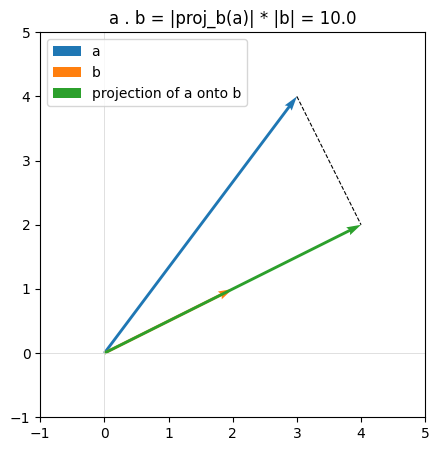

In [4]:
# Quick visual: dot product is "how much of a points along b" times |b|.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(0, color="lightgrey", lw=0.5); ax.axvline(0, color="lightgrey", lw=0.5)
ax.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="C0", label="a")
ax.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1, color="C1", label="b")

# projection of a onto b
proj_len = (a @ b) / np.linalg.norm(b)
proj = proj_len * (b / np.linalg.norm(b))
ax.plot([a[0], proj[0]], [a[1], proj[1]], "k--", lw=0.8)
ax.quiver(0, 0, proj[0], proj[1], angles="xy", scale_units="xy", scale=1,
          color="C2", label="projection of a onto b")

ax.set_xlim(-1, 5); ax.set_ylim(-1, 5); ax.set_aspect("equal")
ax.legend(); ax.set_title(f"a . b = |proj_b(a)| * |b| = {a@b:.1f}")
plt.show()

### Why the dot product = "weighted sum of features"

Suppose a document is described by three hand-designed features:

| feature        | what it counts                 |
|----------------|--------------------------------|
| `mentions_cat` | +1 if "cat" appears, else 0    |
| `mentions_dog` | +1 if "dog" appears, else 0    |
| `is_techy`     | +1 if "neural"/"vector" appear, -1 otherwise |

And a query is described by *weights* — how much we care about each
feature. Then `sim(q, d) = features(d) . weights(q)` is literally a tiny
linear model. The "positive/negative cancellation" is the whole reason
weighted models can be selective:

In [5]:
import numpy as np

def featurize(text):
    t = set(re.findall(r"[a-z0-9]+", text.lower()))
    return np.array([
        1.0 if "cat" in t else 0.0,
        1.0 if "dog" in t else 0.0,
        1.0 if (t & {"neural", "vector", "vectors"}) else -1.0,
    ])

doc_features = np.stack([featurize(d) for d in corpus])
print("document features (mentions_cat, mentions_dog, is_techy):")
for i, f in enumerate(doc_features):
    print(f"  d{i}: {f}")

# I want documents about pets, NOT technical ones:
weights = np.array([1.0, 1.0, -2.0])   # cat=+1, dog=+1, techy=-2
scores = doc_features @ weights

print("\nscores under weights w =", weights)
for i, s in enumerate(scores):
    print(f"  d{i}: score = {s:+.1f}   {corpus[i]!r}")

document features (mentions_cat, mentions_dog, is_techy):
  d0: [ 1.  0. -1.]
  d1: [ 1.  1. -1.]
  d2: [ 0.  0. -1.]
  d3: [0. 0. 1.]
  d4: [0. 0. 1.]

scores under weights w = [ 1.  1. -2.]
  d0: score = +3.0   'the cat sat on the mat'
  d1: score = +4.0   'the cat played with the dog'
  d2: score = +2.0   'dogs and cats are common pets'
  d3: score = -2.0   'neural networks learn vector representations'
  d4: score = -2.0   'vector search uses dot products to rank documents'


Look at the scores: documents about cats and dogs land at the top,
while the "neural networks" / "vector search" documents are *pushed down*
by the `-2.0` weight on `is_techy`. Positive and negative contributions
canceled inside a single inner product. This is the same mechanism every
later embedding model uses, just with hundreds of learned features instead
of three hand-designed ones.

## 1.3 The hidden link: Jaccard *is* a normalized dot product

Let's pull the two ideas together. Represent each document as a **binary
bag-of-words** vector $\mathbf{a} \in \{0,1\}^V$ over the shared vocabulary
$V$ — coordinate $i$ is $1$ iff token $i$ appears in the document. Then:

$$
\mathbf{a}\cdot\mathbf{b} \;=\; \sum_i a_i b_i \;=\; |A \cap B|
$$

because the product $a_i b_i$ is $1$ exactly when token $i$ is in both
documents. And

$$
\lVert\mathbf{a}\rVert_1 + \lVert\mathbf{b}\rVert_1 - \mathbf{a}\cdot\mathbf{b}
\;=\; |A| + |B| - |A \cap B| \;=\; |A \cup B|.
$$

So Jaccard is just a particular *normalization* of the dot product:

$$
\mathrm{Jaccard}(A,B) \;=\; \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert_1 + \lVert\mathbf{b}\rVert_1 - \mathbf{a}\cdot\mathbf{b}}.
$$

The classical view (sets) and the algebraic view (vectors + dot products)
are the same object. That equivalence is what makes the jump to
*embeddings* — dense vectors with real coordinates — feel natural.

In [6]:
import numpy as np

# Build the shared vocabulary from query + corpus.
docs = [query] + corpus
vocab = sorted({t for d in docs for t in tokenize(d)})
vocab_index = {w: i for i, w in enumerate(vocab)}

def bow_binary(text):
    v = np.zeros(len(vocab), dtype=np.float32)
    for t in tokenize(text):
        v[vocab_index[t]] = 1.0
    return v

Q = bow_binary(query)
D = np.stack([bow_binary(d) for d in corpus])

print(f"vocab size = {len(vocab)} (vocab = {vocab})\n")

# Dot-product Jaccard vs the set-based jaccard we wrote earlier:
print(f"{'doc':>4} {'|A∩B|':>6} {'|A∪B|':>6} {'jaccard_vec':>14} {'jaccard_set':>14}")
for i, d in enumerate(corpus):
    inter = float(Q @ D[i])                       # |A ∩ B|
    union = float(Q.sum() + D[i].sum() - inter)   # |A ∪ B|
    j_vec = inter / union if union else 0.0
    j_set = jaccard(tokenize(query), tokenize(d))
    print(f"  d{i} {inter:6.0f} {union:6.0f} {j_vec:14.4f} {j_set:14.4f}")

vocab size = 26 (vocab = ['and', 'are', 'cat', 'cats', 'common', 'documents', 'dog', 'dogs', 'dot', 'learn', 'mat', 'networks', 'neural', 'on', 'pets', 'played', 'products', 'rank', 'representations', 'sat', 'search', 'the', 'to', 'uses', 'vector', 'with'])

 doc  |A∩B|  |A∪B|    jaccard_vec    jaccard_set
  d0      1      7         0.1429         0.1429
  d1      2      6         0.3333         0.3333
  d2      1      8         0.1250         0.1250
  d3      0      8         0.0000         0.0000
  d4      0     11         0.0000         0.0000


The "vector Jaccard" column and the "set Jaccard" column are identical, as
promised. Once you internalize that **classical IR scores are dot products
on cleverly chosen sparse vectors**, all of modern retrieval is the same
pattern with denser, learned vectors.

## 1.4 Sparse retrieval: TF-IDF and BM25

Binary bag-of-words throws away two important signals:

1. **Term frequency (TF).** A document that says "cat" five times is
   probably more about cats than one that says it once.
2. **Inverse document frequency (IDF).** "the" appears everywhere and
   carries no information; "neural" appears rarely and is highly diagnostic.

BM25 (Robertson 1994, still the strongest classical baseline) combines both:

$$
\mathrm{BM25}(q, d) \;=\; \sum_{t \in q} \mathrm{IDF}(t)\;\cdot\;
    \frac{f(t, d)\,(k_1 + 1)}{f(t, d) + k_1\Big(1 - b + b\,\frac{|d|}{\mathrm{avgdl}}\Big)}
$$

Pieces:

- $f(t,d)$ = how often term $t$ occurs in document $d$ (term frequency).
- $|d|$ = length of $d$, $\mathrm{avgdl}$ = average doc length in the corpus.
- $k_1 \in [1.2, 2.0]$ controls TF saturation (more copies of the word
  stop helping after a while).
- $b \in [0, 1]$ controls length normalization (longer docs are
  penalized).
- $\mathrm{IDF}(t) = \log\frac{N - n_t + 0.5}{n_t + 0.5}$ where $N$ is the
  corpus size and $n_t$ the number of docs containing $t$.

There's still a **dot-product view**: BM25 is the dot product of a
sparse query vector (IDFs of query terms) with a sparse document vector
(saturated, length-normalized term frequencies). The same algebraic shape
as everything else.

We'll use the tiny [`rank_bm25`](https://github.com/dorianbrown/rank_bm25)
library — same one used in the HuggingFace cookbook RAG examples.

In [7]:
from rank_bm25 import BM25Okapi

tokenized_corpus = [tokenize(d) for d in corpus]
bm25 = BM25Okapi(tokenized_corpus)            # uses defaults k1=1.5, b=0.75

scores = bm25.get_scores(tokenize(query))
print(f"BM25 scores for query: {query!r}\n")
order = scores.argsort()[::-1]
for rank, i in enumerate(order, 1):
    print(f"  rank {rank}: d{i}  score = {scores[i]:+.4f}   {corpus[i]!r}")

BM25 scores for query: 'cat and dog'

  rank 1: d1  score = +1.4562   'the cat played with the dog'
  rank 2: d2  score = +1.1148   'dogs and cats are common pets'
  rank 3: d0  score = +0.3414   'the cat sat on the mat'
  rank 4: d4  score = +0.0000   'vector search uses dot products to rank documents'
  rank 5: d3  score = +0.0000   'neural networks learn vector representations'


In [8]:
# Side-by-side: Jaccard vs BM25 ranking.
import numpy as np

jac_scores = np.array([jaccard(tokenize(query), tokenize(d)) for d in corpus])

print(f"{'doc':>4}  {'jaccard':>8}  {'bm25':>8}   text")
for i in range(len(corpus)):
    print(f"  d{i}  {jac_scores[i]:8.3f}  {scores[i]:+8.3f}   {corpus[i]!r}")

 doc   jaccard      bm25   text
  d0     0.143    +0.341   'the cat sat on the mat'
  d1     0.333    +1.456   'the cat played with the dog'
  d2     0.125    +1.115   'dogs and cats are common pets'
  d3     0.000    +0.000   'neural networks learn vector representations'
  d4     0.000    +0.000   'vector search uses dot products to rank documents'


Notice how BM25 cleanly separates `d1` ("the cat played with the dog") as
the best match — it gets credit for matching *both* informative query
terms — while Jaccard ties documents that share fewer informative tokens.
That gap is what IDF buys you.

## What we have so far

| similarity        | document representation         | what it captures                   |
|-------------------|---------------------------------|------------------------------------|
| Jaccard           | set of tokens                   | exact token overlap                |
| dot product       | binary BoW (sparse 0/1 vector)  | exact token overlap, count form    |
| TF-IDF / BM25     | weighted BoW (sparse)           | overlap + word-importance + length |
| (next notebook)   | learned dense embedding         | *semantic* similarity              |

Three things to carry into notebook 2:

1. Every score is some kind of inner product between vectors.
2. The classical scores fail when surface forms don't match
   (`"dog"` vs. `"puppy"`, `"car"` vs. `"automobile"`).
3. *Learning* the coordinates of those vectors — instead of hand-designing
   them with TF/IDF — is exactly what embedding models do.